In [29]:
import numpy as np
import pandas as pd
import os

cwd = os.getcwd()
path = os.path.join(cwd, "Iris.csv")

In [30]:
df = pd.read_csv(path)
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [31]:
# remove id
df = df.iloc[:, 1:]
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
# label encoder - change class to numeric
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Species"] = encoder.fit_transform(df["Species"])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\seaborn\_oldcore.py:1075: Future

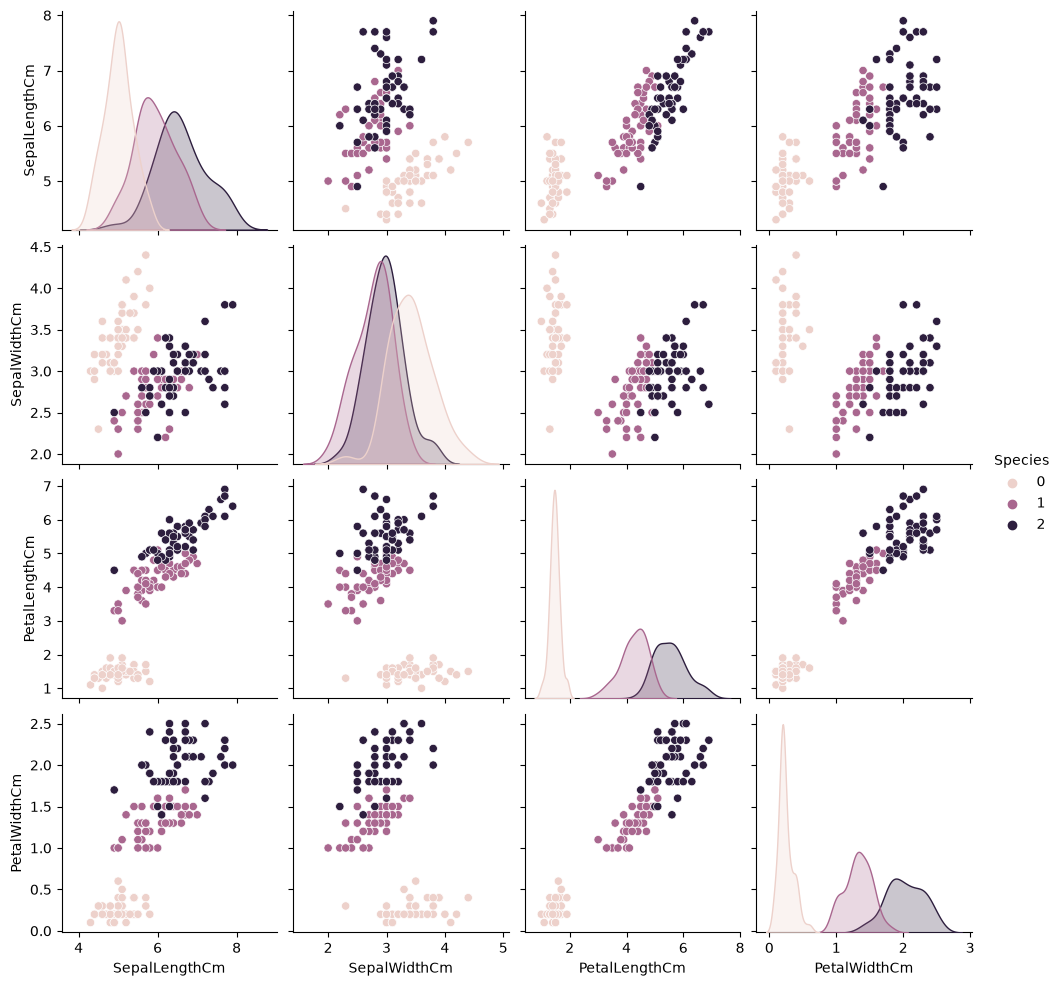

In [33]:
# to make classification difficult
import seaborn as sns

sns.pairplot(df, hue="Species")

In [34]:
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]

In [35]:
df

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1
...,...,...,...
145,3.0,5.2,2
146,2.5,5.0,2
147,3.0,5.2,2
148,3.4,5.4,2


In [36]:
# taking only 10  rows for training

df = df.sample(100) #randomise the data
df_train = df.iloc[:60, :].sample(10)
df_val = df.iloc[60:80, :].sample(5)
df_test = df.iloc[80:100, :].sample(5)


In [37]:
df_train

,SepalWidthCm,PetalLengthCm,Species
89,2.5,4.0,1
142,2.7,5.1,2
72,2.5,4.9,1
63,2.9,4.7,1
93,2.3,3.3,1
126,2.8,4.8,2
70,3.2,4.8,1
99,2.8,4.1,1
51,3.2,4.5,1
97,2.9,4.3,1


In [38]:
df_val

,SepalWidthCm,PetalLengthCm,Species
52,3.1,4.9,1
67,2.7,4.1,1
86,3.1,4.7,1
84,3.0,4.5,1
80,2.4,3.8,1


In [39]:
df_test

,SepalWidthCm,PetalLengthCm,Species
128,2.8,5.6,2
85,3.4,4.5,1
102,3.0,5.9,2
105,3.0,6.6,2
107,2.9,6.3,2


In [40]:
x_test = df_val.iloc[:, 0:2].values
y_test = df_val.iloc[:, -1].values

case 1: Bagging - Row sampling 

In [41]:
# data for tree 1
df_bag = df_train.sample(8, replace=True) # a row can repeat also

x = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
126,2.8,4.8,2
89,2.5,4.0,1
97,2.9,4.3,1
126,2.8,4.8,2
142,2.7,5.1,2
126,2.8,4.8,2
97,2.9,4.3,1
72,2.5,4.9,1


In [42]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.6


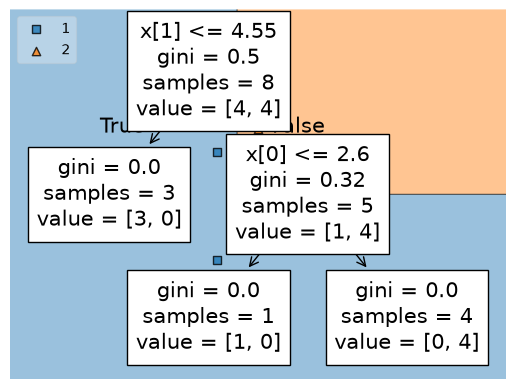

In [43]:

df_bag1 = DecisionTreeClassifier()

evaluate(df_bag1, x, y)

In [44]:
# data for tree 2
df_bag = df_train.sample(8, replace=True) # a row can repeat also

x = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
97,2.9,4.3,1
72,2.5,4.9,1
142,2.7,5.1,2
89,2.5,4.0,1
63,2.9,4.7,1
72,2.5,4.9,1
142,2.7,5.1,2
126,2.8,4.8,2


C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


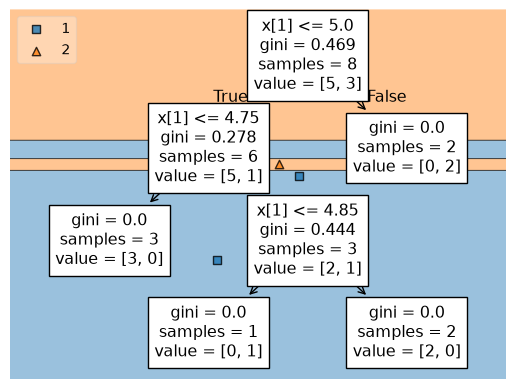

In [45]:

df_bag2 = DecisionTreeClassifier()

evaluate(df_bag2, x, y)

In [47]:
# data for tree 3
df_bag = df_train.sample(8, replace=True) # a row can repeat also

x = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
93,2.3,3.3,1
99,2.8,4.1,1
89,2.5,4.0,1
89,2.5,4.0,1
63,2.9,4.7,1
89,2.5,4.0,1
99,2.8,4.1,1
70,3.2,4.8,1


1.0


C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


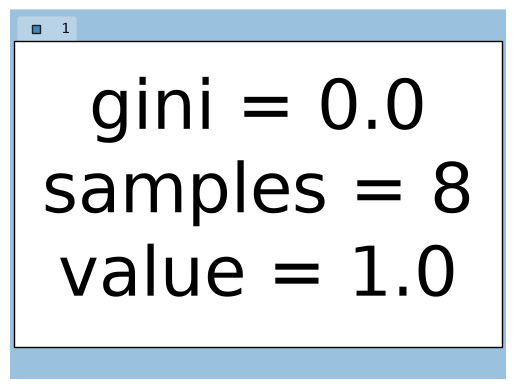

In [48]:

df_bag3 = DecisionTreeClassifier()

evaluate(df_bag3, x, y)

In [46]:
def evaluate(clf, x, y):
    clf.fit(x,y)
    plot_tree(clf)
    plot_decision_regions(x.values, y.values, clf, legend=2)
    print(accuracy_score(y_test, clf.predict(x_test)))

Aggregation

In [49]:
df_test

,SepalWidthCm,PetalLengthCm,Species
128,2.8,5.6,2
85,3.4,4.5,1
102,3.0,5.9,2
105,3.0,6.6,2
107,2.9,6.3,2


In [52]:
print("predicator 1" , df_bag1.predict(np.array([2.8,5.6]).reshape(1,2)))
print("predicator 2" , df_bag2.predict(np.array([2.8,5.6]).reshape(1,2)))
print("predicator 3" , df_bag3.predict(np.array([2.8,5.6]).reshape(1,2)))

predicator 1 [2]
predicator 2 [2]
predicator 3 [1]


C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Tanmay\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


pasting - row sapling but without replacement

In [54]:
df_train
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
99,2.8,4.1,1
51,3.2,4.5,1
97,2.9,4.3,1
142,2.7,5.1,2
93,2.3,3.3,1
72,2.5,4.9,1
70,3.2,4.8,1
63,2.9,4.7,1


Random subspaces - column sampling with or without replacement

In [57]:
df1 = pd.read_csv(path)
df1 = df1.sample(10)
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
20,21,5.4,3.4,1.7,0.2,Iris-setosa
97,98,6.2,2.9,4.3,1.3,Iris-versicolor
106,107,4.9,2.5,4.5,1.7,Iris-virginica
118,119,7.7,2.6,6.9,2.3,Iris-virginica
67,68,5.8,2.7,4.1,1.0,Iris-versicolor
54,55,6.5,2.8,4.6,1.5,Iris-versicolor
48,49,5.3,3.7,1.5,0.2,Iris-setosa
87,88,6.3,2.3,4.4,1.3,Iris-versicolor
119,120,6.0,2.2,5.0,1.5,Iris-virginica
100,101,6.3,3.3,6.0,2.5,Iris-virginica


In [63]:
df1.sample(2, replace=True, axis=1)

,PetalWidthCm,SepalWidthCm
20,0.2,3.4
97,1.3,2.9
106,1.7,2.5
118,2.3,2.6
67,1.0,2.7
54,1.5,2.8
48,0.2,3.7
87,1.3,2.3
119,1.5,2.2
100,2.5,3.3


Random patches - row + column sampling 


In [68]:
df1.sample(8, replace=True).sample(2, replace=True, axis=1)

,SepalLengthCm,PetalLengthCm
118,7.7,6.9
87,6.3,4.4
119,6.0,5.0
54,6.5,4.6
100,6.3,6.0
87,6.3,4.4
100,6.3,6.0
20,5.4,1.7
